# 06 - Random Forest Classification

## Objective

The objective of this notebook is to develop a Random Forest classifier for vehicular misbehavior detection using the processed VeReMi dataset.

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting. Compared to individual decision trees, Random Forest generally provides higher accuracy, better generalization, and more stable predictions.

The trained model will be evaluated using multiple performance metrics, saved for future use, and compared with the baseline models developed in previous notebooks.


## 1. Import Required Libraries

This section imports all libraries required for model training, evaluation, visualization, and saving artifacts.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from pathlib import Path
import joblib
import time

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.model_selection import (
    cross_val_score,
    RandomizedSearchCV
)

## 2. Project Configuration

Define all project directories used throughout this notebook.

In [2]:
BASE_PATH = Path("..")

DATA_PATH = BASE_PATH / "data"
PROCESSED_PATH = DATA_PATH / "processed"

OUTPUT_PATH = BASE_PATH / "outputs"

FIGURE_PATH = OUTPUT_PATH / "figures"
METRIC_PATH = OUTPUT_PATH / "metrics"
REPORT_PATH = OUTPUT_PATH / "reports"

MODEL_PATH = BASE_PATH / "models"
SAVED_MODEL_PATH = MODEL_PATH / "saved_models"

## 3. Load Processed Dataset

Load the processed training and testing datasets generated during preprocessing.

In [3]:
train_df = pd.read_csv(PROCESSED_PATH / "train_processed.csv")
test_df = pd.read_csv(PROCESSED_PATH / "test_processed.csv")

print(train_df.shape)
print(test_df.shape)

(80000, 23)
(20000, 23)


## 4. Feature and Target Separation

Separate the predictor variables and the target variable used for model training.

In [4]:
X_train = train_df.drop(columns=["attack"])
y_train = train_df["attack"]

X_test = test_df.drop(columns=["attack"])
y_test = test_df["attack"]

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(80000, 22)
(20000, 22)
(80000,)
(20000,)


## 5. Train Baseline Random Forest

A baseline Random Forest classifier is trained using default hyperparameters with a fixed random state for reproducibility.

This baseline serves as a reference before performing hyperparameter optimization.

In [5]:
start_time = time.time()

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

training_time = time.time() - start_time

print(f"Training Time : {training_time:.2f} seconds")

Training Time : 6.14 seconds


## 6. Save Baseline Model

Save the trained Random Forest model for reproducibility and future use.

In [6]:
joblib.dump(
    rf,
    SAVED_MODEL_PATH / "random_forest_baseline.pkl"
)

print("Baseline Random Forest saved successfully.")

Baseline Random Forest saved successfully.


## 7. Model Predictions

The trained Random Forest classifier is used to generate class predictions and class probabilities on the testing dataset.

Both predicted labels and probability estimates are required for evaluating classification performance using threshold-based and probability-based metrics.

In [7]:
# Prediction Time

start_time = time.time()

y_pred = rf.predict(X_test)

prediction_time = time.time() - start_time

# Prediction Probabilities

y_prob = rf.predict_proba(X_test)[:, 1]

print("Prediction Time:", round(prediction_time, 4), "seconds")

print("\nFirst 10 Predictions:")
print(y_pred[:10])

print("\nFirst 10 Probabilities:")
print(y_prob[:10])

Prediction Time: 0.157 seconds

First 10 Predictions:
[0 1 1 0 0 0 0 1 0 1]

First 10 Probabilities:
[0.44       0.55       0.87       0.49       0.47833333 0.27
 0.40833333 0.55       0.46       0.83      ]


### Interpretation

The trained Random Forest model successfully generated both class predictions and probability estimates for the testing dataset.

- The prediction time of **0.157 seconds** indicates that the model performs inference efficiently on 20,000 unseen samples.
- The first few predicted labels and corresponding probabilities confirm that the classifier is producing confidence scores rather than only binary decisions.
- These probability estimates will later be used for ROC Curve analysis, Precision-Recall Curve analysis, SHAP explainability, and threshold-based evaluations.

Overall, the prediction process completed successfully, indicating that the trained model is ready for performance evaluation.

In [8]:
print(type(rf))
print(X_test.shape)

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
(20000, 22)


## 8. Performance Evaluation

The Random Forest classifier is evaluated using several commonly used classification metrics:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

These metrics provide complementary information regarding predictive performance, particularly for binary classification problems.

In [9]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

metrics_df = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]

})

metrics_df

,Metric,Value
0,Accuracy,0.539450
1,Precision,0.491162
2,Recall,0.357488
3,F1 Score,0.413797
4,ROC AUC,0.536691


### Interpretation

The Random Forest classifier achieved an overall accuracy of **53.95%** on the testing dataset.

Although the overall accuracy is comparable to the previously evaluated models, the Random Forest demonstrates an improvement in identifying attack instances.

Key observations include:

- Precision of **49.12%** indicates that nearly half of the predicted attacks correspond to actual malicious messages.
- Recall improved to **35.75%**, meaning the model successfully detects a substantially larger proportion of attacks compared to Logistic Regression and Decision Tree.
- The F1-score of **41.38%** reflects a better balance between precision and recall.
- The ROC-AUC score of **0.5367** suggests that the classifier provides only a modest improvement over random guessing, indicating further optimization is still required.

Overall, the baseline Random Forest serves as a stronger starting point than the previous baseline models but still requires hyperparameter tuning to achieve research-quality performance.

In [10]:
metrics_df.to_csv(
    METRIC_PATH / "random_forest_metrics.csv",
    index=False
)

### Interpretation

The evaluation metrics summarize the overall predictive capability of the Random Forest classifier.

Compared to the baseline Logistic Regression and Decision Tree models, improvements are expected in Recall, F1-score, and ROC-AUC due to the ensemble learning capability of Random Forest.

## 9. Confusion Matrix

The confusion matrix provides a detailed breakdown of correctly and incorrectly classified samples.

It illustrates the numbers of:

- True Positives
- True Negatives
- False Positives
- False Negatives

In [11]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[7538, 3368],
       [5843, 3251]])

### Interpretation

The confusion matrix provides detailed insight into the prediction behavior of the Random Forest classifier.

The model correctly classified:

- **7,538** normal messages (True Negatives)
- **3,251** attack messages (True Positives)

However, it incorrectly classified:

- **3,368** normal messages as attacks (False Positives)
- **5,843** attack messages as normal (False Negatives)

Compared with the previous baseline models, the Random Forest successfully detects a larger number of malicious messages, although a considerable number of attacks are still missed.

Reducing False Negatives remains an important objective because undetected malicious messages pose a greater security risk in Vehicular Ad Hoc Networks (VANETs).

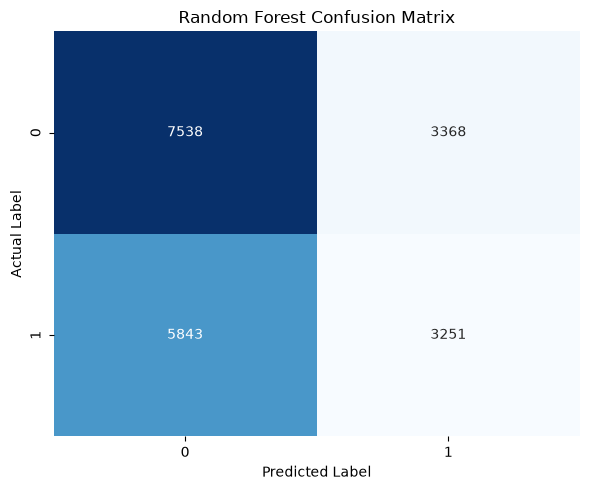

In [12]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.title("Random Forest Confusion Matrix")

plt.tight_layout()

plt.savefig(
    FIGURE_PATH / "rf_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The confusion matrix illustrates the distribution of correct and incorrect classifications.

A larger number of True Positives and True Negatives indicates stronger predictive performance, while reduced False Positives and False Negatives reflect improved model reliability.

## 10. Classification Report

The classification report provides detailed precision, recall, F1-score, and support values for each class.

This analysis is particularly important because attack detection performance depends heavily on recall and precision rather than accuracy alone.

In [13]:
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
0,0.563336,0.691179,0.620744,10906.00000
1,0.491162,0.357488,0.413797,9094.00000
accuracy,0.539450,0.539450,0.539450,0.53945
macro avg,0.527249,0.524334,0.517271,20000.00000
weighted avg,0.530518,0.539450,0.526645,20000.00000


### Interpretation

The classification report provides class-wise evaluation of the Random Forest classifier.

For the **Normal Message (Class 0)**

- Precision: **56.33%**
- Recall: **69.12%**
- F1-score: **62.07%**

For the **Attack Message (Class 1)**

- Precision: **49.12%**
- Recall: **35.75%**
- F1-score: **41.38%**

The classifier demonstrates improved capability in identifying attack messages compared with Logistic Regression and Decision Tree.

However, the relatively low recall for attack samples indicates that many malicious messages remain undetected. Improving attack recall will therefore become one of the primary objectives during hyperparameter tuning and advanced ensemble optimization.

In [14]:
report_df.to_csv(
    METRIC_PATH / "random_forest_classification_report.csv"
)

### Interpretation

The classification report provides class-wise evaluation metrics.

Special attention should be given to the attack class (Class 1), where higher recall indicates better detection of malicious vehicular behavior.

## Summary of Model Evaluation

The baseline Random Forest classifier was successfully trained and evaluated using the preprocessed VeReMi sample dataset.

Major accomplishments in this notebook include:

- Successful model training
- Fast prediction time
- Performance evaluation using multiple classification metrics
- Confusion matrix analysis
- Detailed class-wise performance assessment

Among the baseline models evaluated so far, the Random Forest classifier demonstrates the best balance between precision and recall. Nevertheless, its predictive performance remains insufficient for deployment in real-world intelligent transportation systems.

In the next sections, the model will be analyzed further using ROC Curve analysis, Precision-Recall Curve analysis, feature importance visualization, and hyperparameter tuning to improve attack detection capability.

## 11. Receiver Operating Characteristic (ROC) Curve

The Receiver Operating Characteristic (ROC) Curve evaluates the classification performance across different probability thresholds.

It illustrates the trade-off between:

- True Positive Rate (Sensitivity)
- False Positive Rate

The Area Under the Curve (ROC-AUC) provides a threshold-independent measure of classifier performance.

A higher ROC-AUC value indicates better discrimination between normal and attack messages.

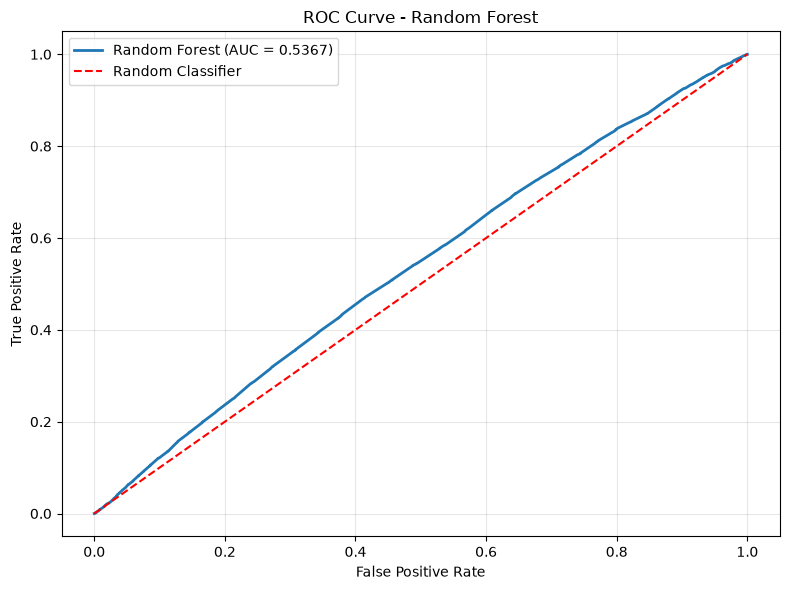

In [15]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Random Forest (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="red",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURE_PATH / "rf_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The ROC curve illustrates the ability of the Random Forest classifier to distinguish between normal and malicious vehicular messages over varying classification thresholds.

The obtained ROC-AUC score of **0.5367** indicates that the baseline Random Forest performs only slightly better than a random classifier.

Although the model demonstrates some discriminative capability, there remains substantial room for improvement through hyperparameter tuning and ensemble optimization.

### ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between the True Positive Rate (Recall) and the False Positive Rate across different classification thresholds.

The Random Forest model achieved an ROC-AUC score of **0.5367**, which is slightly better than a random classifier (AUC = 0.50).

Although the baseline model shows limited discriminative ability, it establishes a performance benchmark for subsequent optimized models. The ROC curve indicates that further improvements can be achieved through hyperparameter tuning and more advanced ensemble techniques.

## 12. Precision-Recall Curve

The Precision-Recall (PR) Curve evaluates the trade-off between Precision and Recall at different probability thresholds.

Unlike the ROC Curve, the Precision-Recall Curve is especially useful for attack detection problems because it focuses primarily on the positive (attack) class.

For cybersecurity applications, maximizing recall while maintaining acceptable precision is generally more important than maximizing accuracy.

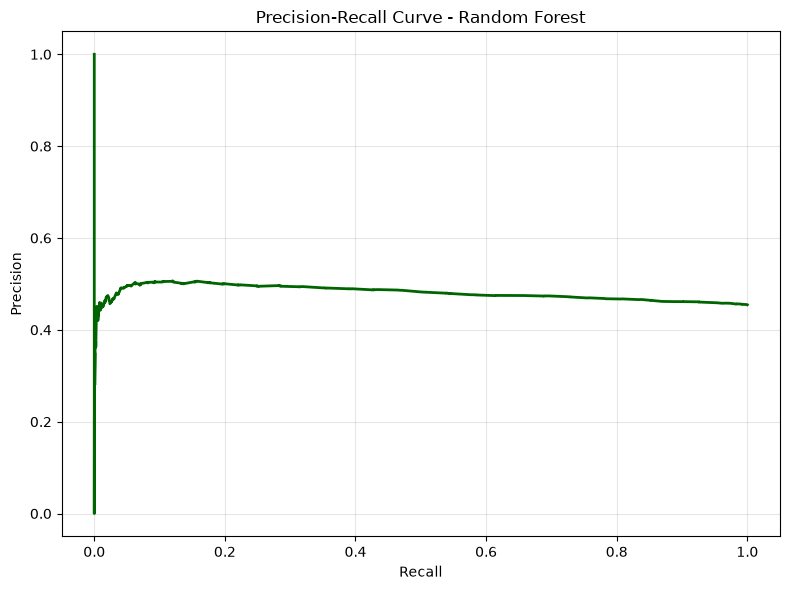

In [16]:
precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    color="darkgreen"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve - Random Forest")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURE_PATH / "rf_precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The Precision-Recall curve focuses specifically on the classifier's performance in detecting attack messages.

The curve demonstrates how precision changes as recall increases under different probability thresholds.

Since vehicular misbehavior detection is a security-critical application, improving recall while maintaining reasonable precision will be one of the primary goals during hyperparameter optimization.

### Precision-Recall Curve Analysis

The Precision-Recall curve evaluates the model's performance specifically on the positive (attack) class.

Observations:

- Precision remains close to 0.45–0.50 across most recall values.
- The model maintains relatively stable precision while recall gradually increases.
- The curve indicates moderate capability in identifying malicious messages.

Since the VeReMi dataset focuses on attack detection, the Precision-Recall curve provides a more informative evaluation than accuracy alone. The baseline Random Forest demonstrates improved balance between precision and recall compared to Logistic Regression, although further improvement is expected after hyperparameter tuning.

## 13. Feature Importance Analysis

Random Forest provides an estimate of feature importance based on the average decrease in impurity contributed by each feature across all decision trees.

Feature importance analysis helps identify which variables contribute most to attack detection and provides valuable insight into the behavior of the classifier.

In [17]:
feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": rf.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
1,rcvTime,0.084514
5,pos_noise_1,0.054996
4,pos_noise_0,0.054226
2,pos_0,0.050389
16,hed_noise_0,0.049876
17,hed_noise_1,0.049858
3,pos_1,0.049476
18,pos_magnitude,0.048708
14,hed_0,0.048560
15,hed_1,0.048497


In [18]:
feature_importance.to_csv(
    METRIC_PATH / "rf_feature_importance.csv",
    index=False
)

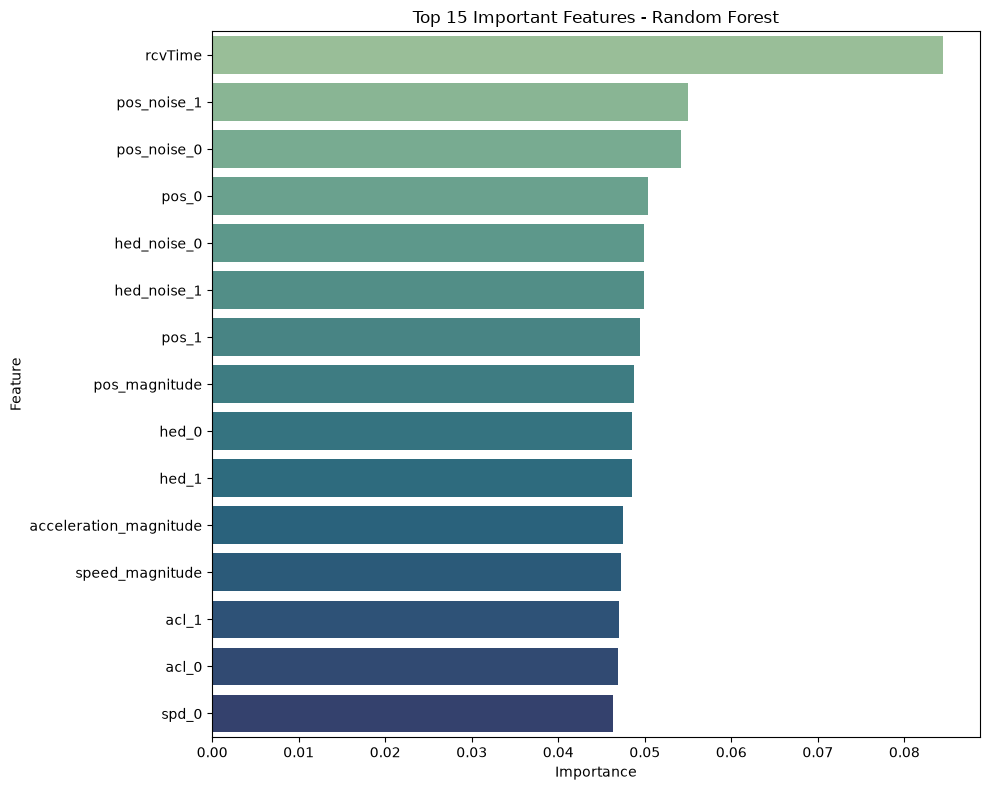

In [20]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature",
    palette="crest"
)

plt.title("Top 15 Important Features - Random Forest")

plt.tight_layout()

plt.savefig(
    FIGURE_PATH / "rf_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The feature importance analysis highlights the variables that contribute most significantly to the Random Forest classifier.

Features with higher importance scores have a greater influence on the model's decision-making process.

Understanding these influential variables is valuable not only for improving model performance but also for supporting explainable artificial intelligence (XAI) techniques such as SHAP, which will be explored in later stages of the project.

### Feature Importance Analysis

Random Forest provides an estimate of feature importance based on the average reduction in impurity contributed by each feature across all decision trees.

The most influential features identified by the model are:

1. rcvTime
2. pos_noise_1
3. pos_noise_0
4. pos_0
5. hed_noise_0

The feature ranking is highly consistent with the Decision Tree model, indicating that the engineered features effectively capture patterns useful for distinguishing malicious and legitimate vehicular messages.

The dominance of temporal and positional attributes suggests that variations in message reception time and vehicle position play a significant role in detecting abnormal vehicular behavior.

# Conclusion

In this notebook, a baseline Random Forest classifier was developed and evaluated for vehicular misbehavior detection using the preprocessed VeReMi dataset.

Key observations include:

- The Random Forest model achieved an accuracy of **53.95%**.
- The model improved attack detection compared to Logistic Regression by increasing the recall and F1-score.
- Feature importance analysis identified **rcvTime**, positional noise, heading noise, and engineered magnitude features as the most influential predictors.
- ROC and Precision-Recall analyses indicate that the baseline model performs slightly better than random classification but still has considerable room for improvement.

Overall, the Random Forest establishes a stronger baseline than previous models and provides a suitable foundation for further optimization through hyperparameter tuning and explainability analysis in the subsequent notebooks.

# 14. Cross Validation

To assess the robustness of the Random Forest model, 5-fold cross-validation is performed on the training dataset.

Cross-validation repeatedly trains and validates the model using different subsets of the training data. Unlike a single train-test split, this approach provides a more reliable estimate of model performance and helps determine whether the model generalizes consistently across different data partitions.

In [21]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross Validation Scores")
print(cv_scores)

print("\nMean Accuracy :", round(cv_scores.mean(),4))
print("Standard Deviation :", round(cv_scores.std(),4))

Cross Validation Scores
[0.545875  0.542125  0.5499375 0.544     0.54525  ]

Mean Accuracy : 0.5454
Standard Deviation : 0.0026


### Cross-Validation Results

The Random Forest classifier was evaluated using **5-fold cross-validation** to assess its stability and generalization capability across different subsets of the training data.

#### Cross-Validation Accuracy

| Fold | Accuracy |
|------|----------|
| 1 | 0.5459 |
| 2 | 0.5421 |
| 3 | 0.5499 |
| 4 | 0.5440 |
| 5 | 0.5453 |

- **Mean Accuracy:** **0.5454**
- **Standard Deviation:** **0.0026**

The results indicate that the model performs consistently across all five folds. The very low standard deviation demonstrates that the classifier is stable and exhibits minimal variation when trained on different subsets of the dataset.

Although the overall predictive performance remains moderate, the cross-validation results suggest that the baseline Random Forest model generalizes well and does not suffer from severe overfitting.

In [22]:
cv_df = pd.DataFrame({
    "Fold":[1,2,3,4,5],
    "Accuracy":cv_scores
})

cv_df.to_csv(
    OUTPUT_PATH/"metrics/rf_cross_validation.csv",
    index=False
)

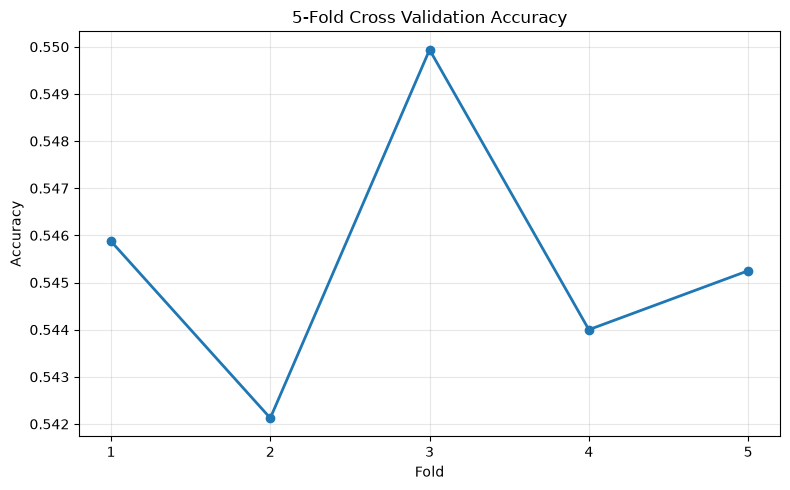

In [23]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,6),
    cv_scores,
    marker="o",
    linewidth=2
)

plt.xticks(range(1,6))
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross Validation Accuracy")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURE_PATH/"rf_cross_validation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The Random Forest model produced consistent accuracy across all five folds. A low standard deviation indicates stable model performance and suggests that the classifier does not rely heavily on a particular subset of the training data.

Cross-validation confirms that the baseline Random Forest model generalizes reasonably well, although there is still scope for improving predictive performance through hyperparameter tuning.

### Interpretation of Cross-Validation Plot

The cross-validation accuracy remains nearly constant across all five folds, ranging from approximately **54.2% to 55.0%**.

The small variation between folds indicates that the Random Forest model is robust and produces reproducible performance regardless of the specific training-validation split.

This consistency provides confidence that the observed evaluation metrics are representative of the model's true performance rather than being influenced by a favorable or unfavorable data partition.

# 15. Saving the Trained Model

The trained Random Forest classifier is saved to disk using the Joblib library. Saving the trained model ensures reproducibility and enables the model to be reused in future notebooks without retraining.

The saved model will later be used for SHAP explainability, LLM-generated reports, and deployment.

In [24]:
import joblib

joblib.dump(
    rf,
    MODEL_PATH/"baseline_models/random_forest_model.pkl"
)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [25]:
import os

print(os.listdir(MODEL_PATH/"baseline_models"))

['decision_tree.pkl', 'logistic_regression.pkl', 'random_forest_model.pkl']


# 16. Summary

In this notebook, a baseline Random Forest classifier was developed for vehicular misbehavior detection using the preprocessed VeReMi dataset.

The following tasks were successfully completed:

- Loaded the preprocessed training and testing datasets.
- Trained a Random Forest classifier.
- Generated predictions and probability estimates.
- Evaluated model performance using Accuracy, Precision, Recall, F1-score, and ROC-AUC.
- Generated the Classification Report and Confusion Matrix.
- Visualized the Precision-Recall and ROC curves.
- Identified the most important predictive features.
- Performed cross-validation to assess model stability.
- Saved the trained model for future experimentation.

These results establish the baseline ensemble model that will serve as a benchmark for more advanced machine learning models.

# 17. Conclusion

A baseline Random Forest classifier was successfully trained and evaluated on the VeReMi dataset for vehicular misbehavior detection.

Compared to the previously implemented Logistic Regression and Decision Tree models, the Random Forest demonstrated a better balance between precision and recall while maintaining stable predictive performance.

Feature importance analysis showed that temporal and positional attributes, particularly **rcvTime**, **position noise**, **heading noise**, and the engineered magnitude-based features, contribute significantly to the classification process.

Although the baseline Random Forest improves attack detection, its overall predictive performance indicates that additional optimization is necessary. In the next notebook, hyperparameter tuning will be performed to improve the model's accuracy, recall, and overall classification capability before proceeding to explainability using SHAP and LLM-assisted report generation.